In [17]:
import sympy as sp
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sympy import symbols, exp, diff, simplify, pprint, latex, init_printing, solve, factorial

init_printing(use_unicode=True)

## Funcion

In [18]:
# Definir las variables simbólicas
x, x0 = symbols('x x_0')

# Definir la función sigmoide
f = 1 / (1 + exp(-(x - x0)))
f

## Series de Taylor

![Alt Text](taylor_series_formula.png)

### Calcular la primera derivada


Primera derivada:


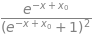

In [19]:
f_prime = diff(f, x)
f_prime_simplified = simplify(f_prime)

print("\nPrimera derivada:")
f_prime

### Calcular la segunda derivada


Segunda derivada:


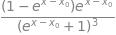

In [20]:
# Calcular la segunda derivada
f_double_prime = diff(f_prime, x)
f_double_prime_simplified = simplify(f_double_prime)

print("\nSegunda derivada:")
f_double_prime
f_double_prime_simplified

### Calcular la tercera derivada


Tercera derivada:


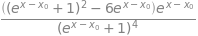

In [21]:
# Calcular la tercera derivada
f_triple_prime = diff(f_double_prime, x)
f_triple_prime_simplified = simplify(f_triple_prime)

print("\nTercera derivada:")
f_triple_prime_simplified

## Leer DataFrame

In [22]:
df = pd.read_csv('Tarea 7 - Compramos el producto\compra_producto.csv')
df.head()

,salario en miles,Probabilidad
0,6,0.04
1,7,0.00
2,8,0.00
3,9,0.00
4,10,0.06


## Graficar el salario en miles y la probabilidad

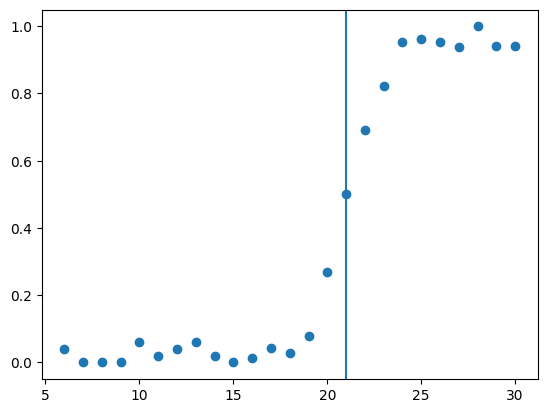

In [23]:
plt.scatter(y=df['Probabilidad'], x=df['salario en miles'])
# salario alrededor de 0.5
# Valor de x_0 cuando la probabilidad es 0.5 o cerca de 0.5, en mi caso era 0.5 exacto.
a = df['salario en miles'].loc[df['Probabilidad']==0.5]
a = int(a.iloc[0])

plt.axvline(a)

## Series de Taylor

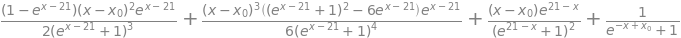

In [24]:
# Series de Taylor
f1 = f_prime.subs({x0: a})
f2 = f_double_prime_simplified.subs({x0: a})
f3 = f_triple_prime_simplified.subs({x0: a})

st = f + f1*(x-x0) + f2/2*(x-x0)**2 + f3/6*(x-x0)**3
st

## Evaluar función de Series de Taylor por cada valor de la tabla

In [25]:
probabilities = list(df['salario en miles'])
approx = []

for prob in probabilities:
    approx.append(st.subs({x: prob, x0: a}))

df_evl = pd.DataFrame({"valores aproximados": approx})
df = pd.concat([df, df_evl], axis=1)
df

,salario en miles,Probabilidad,valores aproximados
0,6,0.0400,-1125*(-6*exp(-15) + (exp(-15) + 1)**2)*exp(-1...
1,7,0.0000,-1372*(-6*exp(-14) + (exp(-14) + 1)**2)*exp(-1...
2,8,0.0000,-2197*(-6*exp(-13) + (exp(-13) + 1)**2)*exp(-1...
3,9,0.0000,-288*(-6*exp(-12) + (exp(-12) + 1)**2)*exp(-12...
4,10,0.0600,-1331*(-6*exp(-11) + (exp(-11) + 1)**2)*exp(-1...
5,11,0.0200,-500*(-6*exp(-10) + (exp(-10) + 1)**2)*exp(-10...
6,12,0.0399,-243*(-6*exp(-9) + (exp(-9) + 1)**2)*exp(-9)/(...
7,13,0.0597,-256*(-6*exp(-8) + (exp(-8) + 1)**2)*exp(-8)/(...
8,14,0.0191,-343*(-6*exp(-7) + (exp(-7) + 1)**2)*exp(-7)/(...
9,15,0.0025,-36*(-6*exp(-6) + (exp(-6) + 1)**2)*exp(-6)/(e...


## Evaluar la función Sigmoide por cada valor de la tabla

In [26]:
probabilities = list(df['salario en miles'])
reales = []

for prob in probabilities:
    reales.append(f.subs({x: prob, x0: a}))

df_evl = pd.DataFrame({"valores reales": reales})
df = pd.concat([df, df_evl], axis=1)
df

,salario en miles,Probabilidad,valores aproximados,valores reales
0,6,0.0400,-1125*(-6*exp(-15) + (exp(-15) + 1)**2)*exp(-1...,1/(1 + exp(15))
1,7,0.0000,-1372*(-6*exp(-14) + (exp(-14) + 1)**2)*exp(-1...,1/(1 + exp(14))
2,8,0.0000,-2197*(-6*exp(-13) + (exp(-13) + 1)**2)*exp(-1...,1/(1 + exp(13))
3,9,0.0000,-288*(-6*exp(-12) + (exp(-12) + 1)**2)*exp(-12...,1/(1 + exp(12))
4,10,0.0600,-1331*(-6*exp(-11) + (exp(-11) + 1)**2)*exp(-1...,1/(1 + exp(11))
5,11,0.0200,-500*(-6*exp(-10) + (exp(-10) + 1)**2)*exp(-10...,1/(1 + exp(10))
6,12,0.0399,-243*(-6*exp(-9) + (exp(-9) + 1)**2)*exp(-9)/(...,1/(1 + exp(9))
7,13,0.0597,-256*(-6*exp(-8) + (exp(-8) + 1)**2)*exp(-8)/(...,1/(1 + exp(8))
8,14,0.0191,-343*(-6*exp(-7) + (exp(-7) + 1)**2)*exp(-7)/(...,1/(1 + exp(7))
9,15,0.0025,-36*(-6*exp(-6) + (exp(-6) + 1)**2)*exp(-6)/(e...,1/(1 + exp(6))


## Calcular el valor absoluto de la diferencia entre los valores aproximados y reales

In [27]:
df['error absoluto'] = abs(df['valores aproximados'] - df['valores reales'])
df.to_csv('output.csv')
df

,salario en miles,Probabilidad,valores aproximados,valores reales,error absoluto
0,6,0.0400,-1125*(-6*exp(-15) + (exp(-15) + 1)**2)*exp(-1...,1/(1 + exp(15)),-225*(1 - exp(-15))*exp(-15)/(2*(exp(-15) + 1)...
1,7,0.0000,-1372*(-6*exp(-14) + (exp(-14) + 1)**2)*exp(-1...,1/(1 + exp(14)),-98*(1 - exp(-14))*exp(-14)/(exp(-14) + 1)**3 ...
2,8,0.0000,-2197*(-6*exp(-13) + (exp(-13) + 1)**2)*exp(-1...,1/(1 + exp(13)),-169*(1 - exp(-13))*exp(-13)/(2*(exp(-13) + 1)...
3,9,0.0000,-288*(-6*exp(-12) + (exp(-12) + 1)**2)*exp(-12...,1/(1 + exp(12)),-72*(1 - exp(-12))*exp(-12)/(exp(-12) + 1)**3 ...
4,10,0.0600,-1331*(-6*exp(-11) + (exp(-11) + 1)**2)*exp(-1...,1/(1 + exp(11)),-121*(1 - exp(-11))*exp(-11)/(2*(exp(-11) + 1)...
5,11,0.0200,-500*(-6*exp(-10) + (exp(-10) + 1)**2)*exp(-10...,1/(1 + exp(10)),-50*(1 - exp(-10))*exp(-10)/(exp(-10) + 1)**3 ...
6,12,0.0399,-243*(-6*exp(-9) + (exp(-9) + 1)**2)*exp(-9)/(...,1/(1 + exp(9)),-81*(1 - exp(-9))*exp(-9)/(2*(exp(-9) + 1)**3)...
7,13,0.0597,-256*(-6*exp(-8) + (exp(-8) + 1)**2)*exp(-8)/(...,1/(1 + exp(8)),-32*(1 - exp(-8))*exp(-8)/(exp(-8) + 1)**3 + 8...
8,14,0.0191,-343*(-6*exp(-7) + (exp(-7) + 1)**2)*exp(-7)/(...,1/(1 + exp(7)),-49*(1 - exp(-7))*exp(-7)/(2*(exp(-7) + 1)**3)...
9,15,0.0025,-36*(-6*exp(-6) + (exp(-6) + 1)**2)*exp(-6)/(e...,1/(1 + exp(6)),-18*(1 - exp(-6))*exp(-6)/(exp(-6) + 1)**3 + 6...


## Grafique los valores aproximados y los reales y analice el resultado

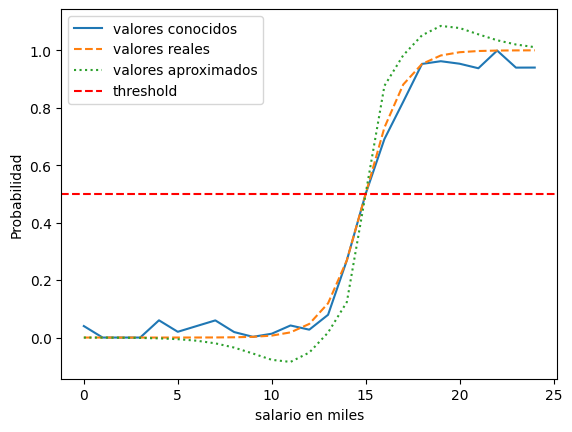

In [30]:
plt.plot(df['Probabilidad'], label='valores conocidos')

plt.plot(df['valores reales'], label='valores reales', linestyle='--',)
plt.plot(df['valores aproximados'], label='valores aproximados', linestyle='dotted')
plt.axhline(0.5, linestyle='--', color='red', label='threshold')
plt.xlabel('salario en miles')
plt.ylabel('Probabilidad')
plt.legend()